# Higgs Batch Run of NEQs=8

This notebook will run through all of the NEQs=8 files and plot the most relevant and important plots for us. 

In [5]:
import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.ticker import ScalarFormatter


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



In [12]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


def batch_dirs_for(NEQS, base_path_root, model_tag="higgs"):
    pattern = os.path.join(
        base_path_root,
        f"neqs{NEQS}_{model_tag}_batch*"
    )
    return sorted(glob.glob(pattern))


def folder_for(NEQS, param_name, value, model_tag="higgs"):
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(NEQS, base_path_root, model_tag=model_tag):
        folder = os.path.join(batch_dir, f"{param_name}_{val_str}")

        if os.path.exists(folder):
            return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in neqs{NEQS}_{model_tag}_batch*"
    )


def load_path_data(NEQS, param_name, value, model_tag="higgs"):
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS,
        param_name,
        value,
        model_tag=model_tag
    )

    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat"
    )

    return pd.read_csv(file_path, sep=r"\s+", header=None).values


def load_specs(NEQS, param_name, value, model_tag="higgs"):
    folder = folder_for(
        NEQS,
        param_name,
        value,
        model_tag=model_tag
    )

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


def get_base_dir(NEQS, param_name, base_value, base_path_root, model_tag="higgs"):
    val_str = f"{base_value:.10e}"

    for batch_dir in batch_dirs_for(NEQS, base_path_root, model_tag=model_tag):
        folder = os.path.join(batch_dir, f"{param_name}_{val_str}")

        if os.path.exists(folder):
            return folder

    raise FileNotFoundError(
        f"Missing base folder for {param_name}_{val_str} in neqs{NEQS}_{model_tag}_batch*"
    )


def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root,
    model_tag="higgs",
    show_summary=True
):
    values = []

    for batch_dir in batch_dirs_for(NEQS, base_path_root, model_tag=model_tag):
        pattern = os.path.join(batch_dir, f"{param_name}_*")
        dirs = glob.glob(pattern)

        for d in dirs:
            try:
                base = os.path.basename(d)
                val_str = base.replace(f"{param_name}_", "")

                # Handles duplicate folders like lam5_xxx_trial_000123
                val_str = val_str.split("_trial_")[0]

                val = float(val_str)
                label = rf"${param_name} = {val:.1e}$"
                values.append((val, label))

            except Exception as e:
                print(f"Skipping {d}: {e}")

    values = sorted(set(values), key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")

        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")

        print(f"{'='*60}\n")

    return values

In [20]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

In [21]:
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]


def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(k, P):
    k, P = prepare_increasing(k, P)
    P_ref = np.interp(k_ref, k, P)
    return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac

In [22]:
LAM_BASE = {
    8: ("lam5", -8.92461e-9),
}

#neqs8
base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(
        NEQS,
        param_name,
        base_val,
        base_path_root,
        model_tag="higgs"
    )

    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

    
#define param values
lam5_values = get_param_values_from_dirs(
    8,
    "lam5",
    base_path_root,
    model_tag="higgs"
)


#check names of batch model we ran through
for d in batch_dirs_for(8, base_path_root, model_tag="higgs"):
    print(d)

    
#check number of models per batch
for d in batch_dirs_for(8, base_path_root, model_tag="higgs"):

    pattern = os.path.join(d, "lam5_*")
    count = len(glob.glob(pattern))

    print(os.path.basename(d), count)
    


NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch001/lam5_-8.9246100000e-09

Summary for NEQS=8, parameter=lam5
Total models found: 200
Parameter range: -4.983e-05 to 1.124e-05

/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch001
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch002
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch003
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch004
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_pote

In [26]:
def load_batch_summaries(NEQS, base_path_root, model_tag="higgs"):
    summary_files = []

    for batch_dir in batch_dirs_for(NEQS, base_path_root, model_tag=model_tag):
        summary_file = os.path.join(batch_dir, f"neqs{NEQS}_summary.csv")

        if os.path.exists(summary_file):
            summary_files.append(summary_file)

    dfs = []

    for f in summary_files:
        df = pd.read_csv(f)
        df["summary_file"] = f
        df["batch_dir"] = os.path.basename(os.path.dirname(f))
        dfs.append(df)

    if len(dfs) == 0:
        raise FileNotFoundError("No batch summary files found.")

    return pd.concat(dfs, ignore_index=True)


#to load them all
summary_all = load_batch_summaries(
    8,
    base_path_root,
    model_tag="higgs"
)

summary_all.head()

,accepted_index,trial_index,lam3,lam4,lam5,r,n_s,alpha_s,Nefolds,original_end_index,original_N_end,original_N_before_end,original_N_after_end,original_eps_end,spectrum_N_start,path_N_end,calc_ret,outdir,summary_file,batch_dir
0,1,1,-0.000005,6.870650e-08,-8.924610e-09,0.002737,0.969485,-0.000470,60,121,946.349733,946.349733,946.349733,1.0,0.000156,60.0,nontrivial,/Users/epmeador/Desktop/research/rwarthur/infl...,/Users/epmeador/Desktop/research/rwarthur/infl...,neqs8_higgs_batch001
1,2,1101,-0.000166,-3.208685e-04,-4.373657e-05,0.003300,0.966235,0.000146,60,246,940.508956,940.508956,940.508956,1.0,0.000156,60.0,nontrivial,/Users/epmeador/Desktop/research/rwarthur/infl...,/Users/epmeador/Desktop/research/rwarthur/infl...,neqs8_higgs_batch001
2,3,2251,0.001964,2.442557e-04,9.643294e-07,0.003319,0.967556,-0.004848,60,198,940.334827,940.334827,940.334827,1.0,0.000156,60.0,nontrivial,/Users/epmeador/Desktop/research/rwarthur/infl...,/Users/epmeador/Desktop/research/rwarthur/infl...,neqs8_higgs_batch001
3,4,2998,-0.000300,-3.549946e-04,-4.617573e-05,0.003669,0.964078,-0.000770,60,247,937.451091,937.451091,937.451091,1.0,0.000156,60.0,nontrivial,/Users/epmeador/Desktop/research/rwarthur/infl...,/Users/epmeador/Desktop/research/rwarthur/infl...,neqs8_higgs_batch001
4,5,4896,-0.001279,-2.738591e-04,-1.666564e-05,0.003532,0.965231,-0.002439,60,247,938.555825,938.555825,938.555825,1.0,0.000156,60.0,nontrivial,/Users/epmeador/Desktop/research/rwarthur/infl...,/Users/epmeador/Desktop/research/rwarthur/infl...,neqs8_higgs_batch001


Let's examine the scalar and power spectra for each of these models!

In [27]:
def plot_filtered_spectra_by_ns_colored_by_Nend(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    Nend_min=None,
    Nend_max=None,
    cmap_name="plasma",
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "figure.titlesize": 24,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def load_observables_from_summary(value):
        summary_all = load_batch_summaries(
            NEQS,
            base_path_root,
            model_tag=model_tag
        )

        row_match = summary_all.loc[
            np.isclose(summary_all[scan_name], value)
        ]

        if len(row_match) == 0:
            raise FileNotFoundError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        row = row_match.iloc[0]

        return (
            row["r"],
            row["n_s"],
            row["alpha_s"],
            row["original_N_end"],
        )

    def load_specs_batch(value):
        folder = folder_for(
            NEQS,
            scan_name,
            value,
            model_tag=model_tag
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref_local(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(
        x_base,
        y_base,
        x_cmp,
        y_cmp,
        xmin=None,
        xmax=None,
    ):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base, Nend_base = load_observables_from_summary(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs_batch(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref_local(
        k_s_base_raw,
        Ps_base_raw,
        k_ref
    )

    k_t_base, Pt_base_norm = normalize_at_ref_local(
        k_t_base_raw,
        Pt_base_raw,
        k_ref
    )

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s, N_end = load_observables_from_summary(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_batch(lamX)

            k_s, Ps_norm = normalize_at_ref_local(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref_local(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep_ns = ns_min <= ns <= ns_max

            keep_Nend = True

            if Nend_min is not None:
                keep_Nend &= N_end >= Nend_min

            if Nend_max is not None:
                keep_Nend &= N_end <= Nend_max

            keep = keep_ns and keep_Nend

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "original_N_end": N_end,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep_ns,
                "kept_by_Nend_cut": keep_Nend,
                "kept": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Base original_N_end: {Nend_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {stats_df['kept_by_ns_cut'].sum()}")
    print(f"Models kept after all cuts: {len(kept_df)}")

    if len(kept_models) == 0:
        print("No models passed the cuts.")
        return stats_df, kept_df

    Nends_kept = np.array([m["original_N_end"] for m in kept_models])

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(
        vmin=np.nanmin(Nends_kept),
        vmax=np.nanmax(Nends_kept),
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    for m in kept_models:
        color = cmap(norm(m["original_N_end"]))

        mask_ps_plot = scalar_k_mask(m["k_s"])

        ax_ps.loglog(
            m["k_s"][mask_ps_plot],
            m["Ps_norm"][mask_ps_plot],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_pt.loglog(
            m["k_t"],
            m["Pt_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_ps_err.semilogx(
            m["k_ps_err"],
            100.0 * m["frac_ps"],
            color=color,
            lw=1.5,
            alpha=0.85,
        )

        ax_pt_err.semilogx(
            m["k_pt_err"],
            100.0 * m["frac_pt"],
            color=color,
            lw=1.5,
            alpha=0.85,
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$N_{\rm end}^{\rm original}$")
    cbar.ax.tick_params(direction="in")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"NEQS={NEQS} Higgs models with ${ns_min} \leq n_s \leq {ns_max}$, "
        rf"colored by $N_{{\rm end}}^{{\rm original}}$",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"colored_by_original_Nend.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    kept_df = kept_df.sort_values("original_N_end")

    print("\n=== Filtered models ===")
    print(
        kept_df[[
            "lamX",
            "ns",
            "r",
            "alpha_s",
            "original_N_end",
            "mean_dPs_pct",
            "max_dPs_pct",
            "mean_dPt_pct",
            "max_dPt_pct",
        ]].to_string(index=False)
    )

    return stats_df, kept_df


=== All models summary ===
Total loaded: 200
Base ns: 0.969485
Base original_N_end: 946.349733
Models in ns window [0.96, 0.97]: 200
Models kept after all cuts: 200


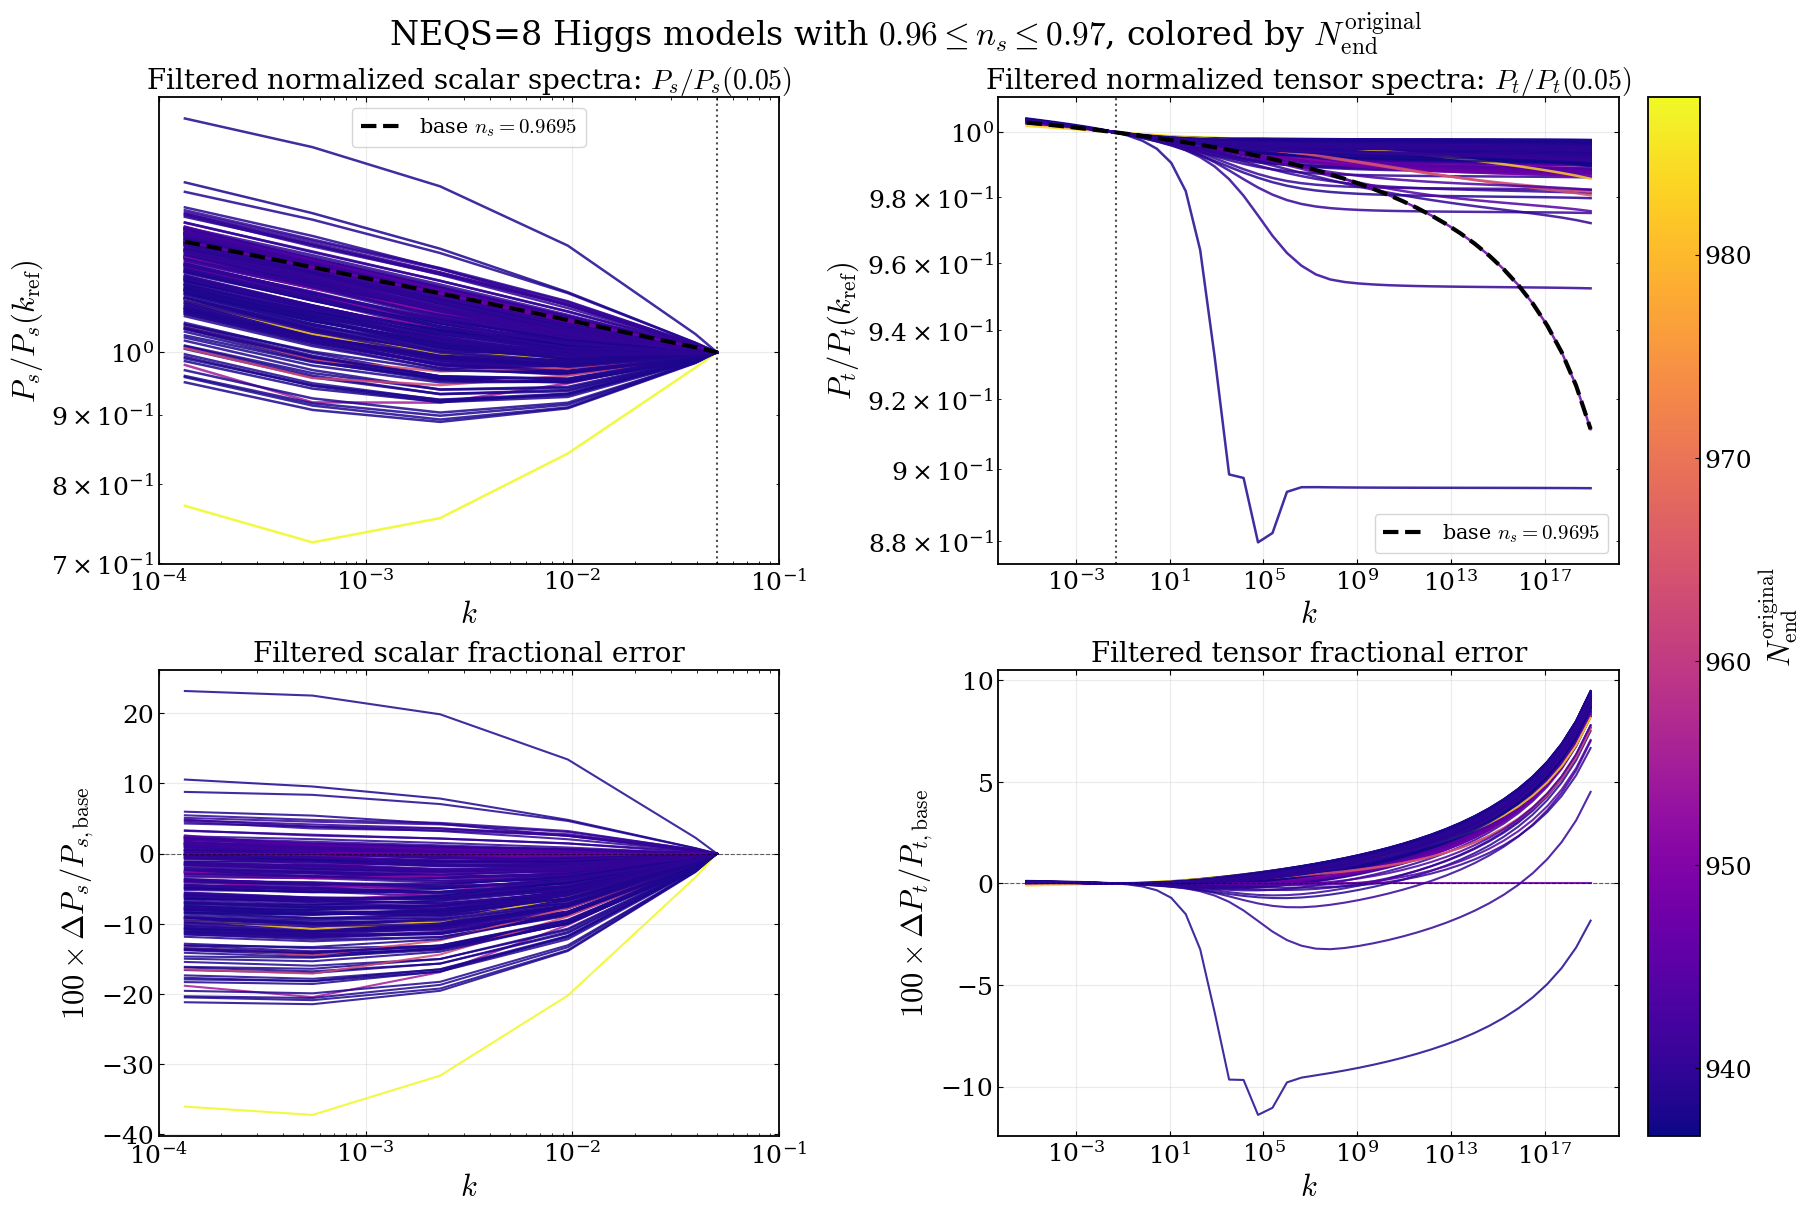


=== Filtered models ===
         lamX       ns        r   alpha_s  original_N_end  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
 1.669515e-06 0.968979 0.003732  0.003273      936.671220     -4.004677     6.683131      1.500607     8.586657
-1.213912e-05 0.968614 0.003732  0.003238      936.687450     -4.453377     7.283118      1.632640     9.029984
-1.492334e-05 0.967344 0.003733  0.002308      936.758352     -3.289266     5.450529      1.608850     8.994905
-9.255990e-06 0.965240 0.003723  0.000419      936.967830     -0.628954     1.218231      1.443787     8.659057
-3.985960e-05 0.965332 0.003689  0.000811      937.214781     -2.137549     3.492186      1.652997     9.113177
-3.346553e-05 0.967663 0.003672  0.003196      937.216380     -4.972185     8.035630      1.711470     9.206019
-6.855818e-06 0.968377 0.003652  0.003910      937.333798     -5.269933     8.697096      1.669404     9.089520
-4.478045e-05 0.965666 0.003668  0.001190      937.362625     -2.699382     4.2

In [29]:
stats_df, kept_df = plot_filtered_spectra_by_ns_colored_by_Nend(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.97,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="paper_higgs_neqs8_lam5_filtered_ns_spectra_colored_by_Nend.pdf"
)

Check N ranges:

In [56]:
def plot_deltaN_histogram_neqs8(
    base_path_root,
    base8_value=-8.92461e-9,
    model_tag="higgs",
    ns_min=None,
    ns_max=None,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    bins=30,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    NEQS = 8
    param = "lam5"

    df = load_batch_summaries(
        NEQS,
        base_path_root,
        model_tag=model_tag,
    ).copy()

    base_row = df.loc[np.isclose(df[param], base8_value)]

    if len(base_row) == 0:
        raise ValueError(
            f"Could not find base {param}={base8_value:.10e} "
            f"in neqs{NEQS}_{model_tag}_batch* summaries"
        )

    base_N_end = float(base_row.iloc[0]["original_N_end"])

    df["deltaN_from_base"] = df["original_N_end"] - base_N_end
    df["abs_deltaN_from_base"] = np.abs(df["deltaN_from_base"])

    # Apply cuts
    if ns_min is not None:
        df = df[df["n_s"] >= ns_min].copy()

    if ns_max is not None:
        df = df[df["n_s"] <= ns_max].copy()

    if r_min is not None:
        df = df[df["r"] >= r_min].copy()

    if r_max is not None:
        df = df[df["r"] <= r_max].copy()

    if max_abs_alpha_s is not None:
        df = df[np.abs(df["alpha_s"]) <= max_abs_alpha_s].copy()

    fig, ax = plt.subplots(
        figsize=(10, 6.5),
        constrained_layout=True,
    )

    ax.hist(
        df["deltaN_from_base"],
        bins=bins,
        color="mediumslateblue",
        alpha=0.78,
        edgecolor="black",
        linewidth=0.9,
    )

    ax.axvline(
        0.0,
        color="black",
        ls="--",
        lw=2.0,
        label="reference model",
    )

    ax.set_title(
        rf"NEQS=8 {model_tag} $\lambda_5$ scan"
    )

    ax.set_xlabel(
        r"$\Delta N_{\rm end}"
        r"=N_{\rm end}-N_{\rm end,ref}$"
    )

    ax.set_ylabel("number of models")
    ax.grid(True, alpha=0.25)

    ax.legend(
        frameon=False,
        loc="upper right",
    )

    title = (
        r"Distribution of inflationary-duration offsets "
        rf"for NEQS=8 {model_tag} batches"
    )

    cuts = []

    if ns_min is not None or ns_max is not None:
        cuts.append(
            rf"${ns_min} < n_s < {ns_max}$"
        )

    if r_min is not None or r_max is not None:
        cuts.append(
            rf"${r_min} < r < {r_max}$"
        )

    if max_abs_alpha_s is not None:
        cuts.append(
            rf"$|\alpha_s| < {max_abs_alpha_s}$"
        )

    if len(cuts) > 0:
        title += "\n" + ", ".join(cuts)

    fig.suptitle(
        title,
        fontsize=20,
    )

    print("\n" + "=" * 70)
    print(rf"NEQS=8, {model_tag} $\lambda_5$ batch scan")
    print("=" * 70)

    print(f"N models shown: {len(df)}")
    print(f"reference original_N_end = {base_N_end:.6f}")

    if max_abs_alpha_s is not None:
        print(f"Applied alpha cut: |alpha_s| <= {max_abs_alpha_s}")

    print("\nDeltaN statistics:")
    print(
        df["deltaN_from_base"]
        .describe()
        .to_string()
    )

    print("\nLargest |deltaN| models:")
    print(
        df[[
            param,
            "n_s",
            "r",
            "alpha_s",
            "original_N_end",
            "deltaN_from_base",
            "abs_deltaN_from_base",
            "batch_dir",
        ]]
        .sort_values(
            "abs_deltaN_from_base",
            ascending=False,
        )
        .head(20)
        .to_string(index=False)
    )

    print("\nClosest-to-reference models:")
    print(
        df[[
            param,
            "n_s",
            "r",
            "alpha_s",
            "original_N_end",
            "deltaN_from_base",
            "abs_deltaN_from_base",
            "batch_dir",
        ]]
        .sort_values(
            "abs_deltaN_from_base",
            ascending=True,
        )
        .head(20)
        .to_string(index=False)
    )

    if save_name is None:
        save_name = (
            f"deltaN_histogram_neqs8_{model_tag}_batches.png"
        )

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return df


NEQS=8, higgs $\lambda_5$ batch scan
N models shown: 152
reference original_N_end = 946.349733
Applied alpha cut: |alpha_s| <= 0.005

DeltaN statistics:
count    152.000000
mean      -6.585039
std        2.053431
min       -9.678513
25%       -7.898807
50%       -7.009721
75%       -6.023925
max        0.821625

Largest |deltaN| models:
     lam5      n_s        r   alpha_s  original_N_end  deltaN_from_base  abs_deltaN_from_base            batch_dir
 0.000002 0.968979 0.003732  0.003273      936.671220         -9.678513              9.678513 neqs8_higgs_batch004
-0.000012 0.968614 0.003732  0.003238      936.687450         -9.662283              9.662283 neqs8_higgs_batch002
-0.000015 0.967344 0.003733  0.002308      936.758352         -9.591381              9.591381 neqs8_higgs_batch003
-0.000009 0.965240 0.003723  0.000419      936.967830         -9.381903              9.381903 neqs8_higgs_batch001
-0.000040 0.965332 0.003689  0.000811      937.214781         -9.134952              

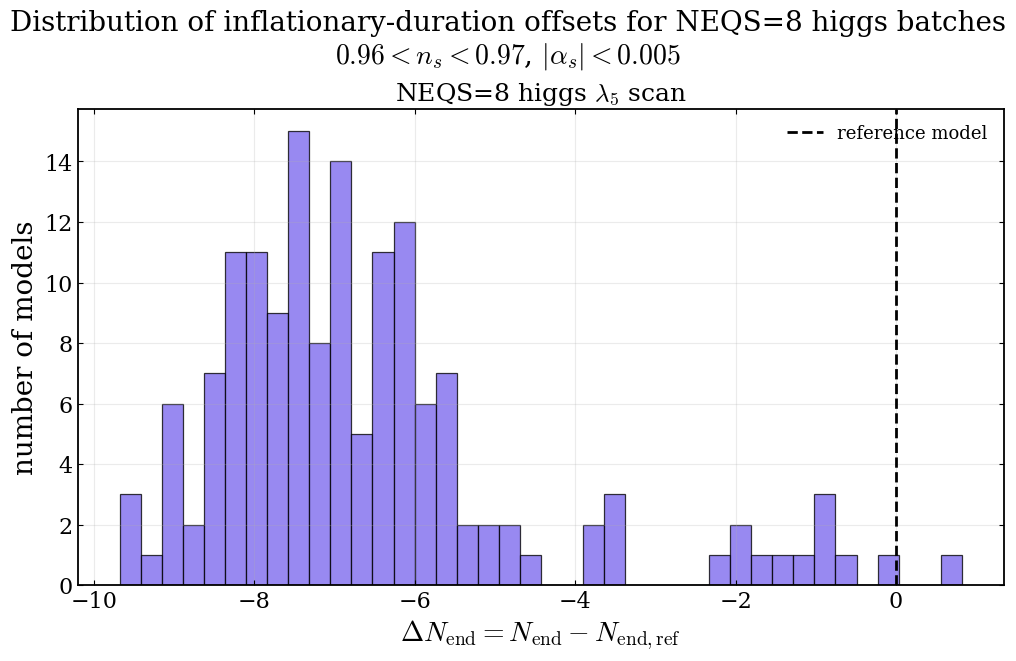

In [60]:
df8 = plot_deltaN_histogram_neqs8(
    base_path_root=base_path_root,
    base8_value=-8.92461e-9,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=0.005,
    bins=40,
    save_name="neqs8_higgs_batches_deltaN_histogram_alpha005.png",
)

The ones with large N:

In [34]:
def plot_large_deltaN_backgrounds(
    df,
    base_path_root,
    base8_value=-8.92461e-9,
    deltaN_min=20.0,
    model_tag="higgs",
    max_models=None,
    normalize=True,
    N_ref=60.0,
    N_window=None,
    save_name=None,
    show=True,
):
    NEQS = 8
    param_name = "lam5"

    # -----------------------------
    # Styling
    # -----------------------------
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    # -----------------------------
    # Helpers
    # -----------------------------
    def load_model_path(lam5_value):
        val_str = f"{lam5_value:.10e}"

        folder = folder_for(
            NEQS,
            param_name,
            lam5_value,
            model_tag=model_tag
        )

        path_file = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat"
        )

        return pd.read_csv(path_file, sep=r"\s+", header=None).values

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def prepare_curve(N, Y):
        N, Y = prepare_increasing(N, Y)

        if normalize:
            if not (N.min() <= N_ref <= N.max()):
                raise ValueError(
                    f"N_ref={N_ref} outside range [{N.min()}, {N.max()}]"
                )

            Y_ref = np.interp(N_ref, N, Y)

            if np.abs(Y_ref) < 1e-30:
                raise ValueError(f"Reference value too small at N_ref={N_ref}")

            Y = Y / Y_ref

        N, Y = apply_N_window(N, Y)

        return N, Y

    # -----------------------------
    # Load base model
    # -----------------------------
    base_path = load_model_path(base8_value)

    H_base = base_path[:, 1]
    eps_base = base_path[:, 2]
    N_base = base_path[:, NEQS]

    N_H_base, H_base_plot = prepare_curve(N_base, H_base)
    N_eps_base, eps_base_plot = prepare_curve(N_base, eps_base)

    # -----------------------------
    # Select large deltaN models
    # -----------------------------
    selected = df[
        df["abs_deltaN_from_base"] >= deltaN_min
    ].copy()

    selected = selected.sort_values(
        "abs_deltaN_from_base",
        ascending=False
    )

    if max_models is not None:
        selected = selected.head(max_models)

    if len(selected) == 0:
        print(f"No models found with |deltaN| >= {deltaN_min}")
        return selected

    print("\nSelected large-|deltaN| models:")
    print(
        selected[[
            param_name,
            "n_s",
            "r",
            "alpha_s",
            "original_N_end",
            "deltaN_from_base",
            "abs_deltaN_from_base",
            "batch_dir",
        ]].to_string(index=False)
    )

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5.8),
        constrained_layout=True,
    )

    ax_H, ax_eps = axes

    cmap = plt.get_cmap("plasma")
    norm = mcolors.Normalize(
        vmin=selected["abs_deltaN_from_base"].min(),
        vmax=selected["abs_deltaN_from_base"].max(),
    )

    for _, row in selected.iterrows():
        lam5 = row[param_name]
        color = cmap(norm(row["abs_deltaN_from_base"]))

        try:
            path = load_model_path(lam5)

            H = path[:, 1]
            eps = path[:, 2]
            N = path[:, NEQS]

            N_H, H_plot = prepare_curve(N, H)
            N_eps, eps_plot = prepare_curve(N, eps)

            label = (
                rf"$\Delta N={row['deltaN_from_base']:.2f}$, "
                rf"$n_s={row['n_s']:.4f}$"
            )

            ax_H.plot(
                N_H,
                H_plot,
                lw=1.8,
                alpha=0.85,
                color=color,
                label=label,
            )

            ax_eps.plot(
                N_eps,
                eps_plot,
                lw=1.8,
                alpha=0.85,
                color=color,
            )

        except Exception as e:
            print(f"Skipping lam5={lam5:.5e}: {e}")

    # Base model
    ax_H.plot(
        N_H_base,
        H_base_plot,
        color="black",
        lw=3.0,
        ls="--",
        label="base model",
    )

    ax_eps.plot(
        N_eps_base,
        eps_base_plot,
        color="black",
        lw=3.0,
        ls="--",
        label="base model",
    )

    if normalize:
        ax_H.set_ylabel(r"$H/H(N_{\rm ref})$")
        ax_eps.set_ylabel(r"$\epsilon/\epsilon(N_{\rm ref})$")
    else:
        ax_H.set_ylabel(r"$H(N)$")
        ax_eps.set_ylabel(r"$\epsilon(N)$")

    ax_H.set_xlabel(r"$N$")
    ax_eps.set_xlabel(r"$N$")

    ax_H.set_title(r"Hubble evolution")
    ax_eps.set_title(r"Slow-roll evolution")

    ax_H.invert_xaxis()
    ax_eps.invert_xaxis()

    for ax in axes:
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

    ax_H.legend(frameon=False, fontsize=9)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$|\Delta N_{\rm end}|$")
    cbar.ax.tick_params(direction="in")

    fig.suptitle(
        rf"NEQS=8 models with $|\Delta N_{{\rm end}}| \geq {deltaN_min}$",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs8_large_deltaN_backgrounds_min{deltaN_min}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return selected


Selected large-|deltaN| models:
     lam5      n_s        r  alpha_s  original_N_end  deltaN_from_base  abs_deltaN_from_base            batch_dir
-0.000038 0.967206 0.003294 0.057340      987.732591         41.382858             41.382858 neqs8_higgs_batch001
-0.000010 0.961813 0.001890 0.014619      982.811756         36.462023             36.462023 neqs8_higgs_batch002


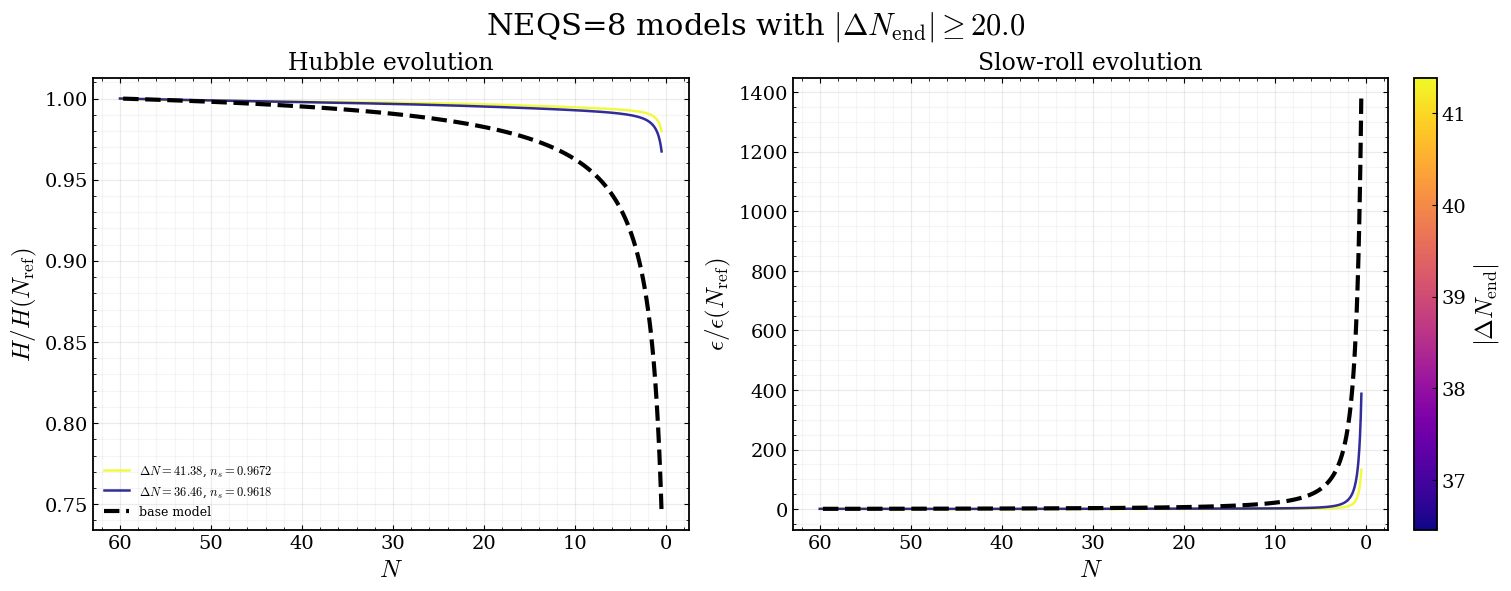

In [35]:
large_deltaN_df = plot_large_deltaN_backgrounds(
    df=df8,
    base_path_root=base_path_root,
    base8_value=-8.92461e-9,
    deltaN_min=20.0,
    model_tag="higgs",
    max_models=None,
    normalize=True,
    N_ref=60.0,
    N_window=(0.5, 60),
    save_name="neqs8_higgs_large_deltaN_H_eps_comparison.png",
)

With the shift in N:

In [43]:
def plot_valid_ns_before_after_kshift_envelopes_rminmax_tensorK_batch(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    model_tag="higgs",
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    alpha_min=None,
    alpha_max=None,
    max_abs_alpha_s=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    k_min_tensor=None,
    k_max_tensor=None,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    summary_cache = {}

    def get_summary(NEQS):
        if NEQS not in summary_cache:
            summary_cache[NEQS] = load_batch_summaries(
                NEQS,
                base_path_root,
                model_tag=model_tag,
            )
        return summary_cache[NEQS]

    def get_summary_row(NEQS, param_name, value):
        summary_df = get_summary(NEQS)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return matches.iloc[0]

    def load_observables(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return row["r"], row["n_s"], row["alpha_s"]

    def get_original_N_end(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return float(row["original_N_end"])

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(
            NEQS,
            param_name,
            value,
            model_tag=model_tag,
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmin=None, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)
        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs

    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_alpha": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if alpha_min is not None and alpha_s < alpha_min:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if alpha_max is not None and alpha_s > alpha_max:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if max_abs_alpha_s is not None and np.abs(alpha_s) > max_abs_alpha_s:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                idx_ps_sh = np.nanargmax(np.abs(frac_ps_sh))
                idx_pt_sh = np.nanargmax(np.abs(frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,

                    "k_min_scalar": k_min_scalar,
                    "k_max_scalar": k_max_scalar,
                    "k_min_tensor": k_min_tensor,
                    "k_max_tensor": k_max_tensor,

                    "max_abs_deltaN_cut": max_abs_deltaN,
                    "max_abs_alpha_s_cut": max_abs_alpha_s,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),

                    "mean_Ps_unshift_pct": 100.0 * np.nanmean(np.abs(frac_ps_un)),
                    "mean_Ps_shift_pct": 100.0 * np.nanmean(np.abs(frac_ps_sh)),
                    "mean_Pt_unshift_pct": 100.0 * np.nanmean(np.abs(frac_pt_un)),
                    "mean_Pt_shift_pct": 100.0 * np.nanmean(np.abs(frac_pt_sh)),

                    "k_max_Ps_shift": k_ps_sh[idx_ps_sh],
                    "k_max_Pt_shift": k_pt_sh[idx_pt_sh],
                    "signed_frac_Ps_shift_at_max": 100.0 * frac_ps_sh[idx_ps_sh],
                    "signed_frac_Pt_shift_at_max": 100.0 * frac_pt_sh[idx_pt_sh],
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            mean_abs = mean_abs[mask]
            max_abs = max_abs[mask]

            if len(k_env) == 0:
                continue

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.2,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.20,
                label=rf"NEQS={NEQS} max",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "k_min_tensor": k_min_tensor if "Pt" in key else np.nan,
                "k_max_tensor": k_max_tensor if "Pt" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "max_abs_alpha_s_cut": max_abs_alpha_s,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        if "Pt" in key:
            k_N60 = 0.05
            k_N20 = 1e15

            ax.axvline(k_N60, color="darkgreen", ls="--", lw=2.0, alpha=0.9)
            ax.axvline(k_N20, color="firebrick", ls="--", lw=2.0, alpha=0.9)

            ax.text(
                k_N60,
                0.82,
                r"$N\sim60$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="darkgreen",
                ha="right",
                va="top",
                fontsize=10,
            )

            ax.text(
                k_N20,
                0.82,
                r"$N\sim20$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="firebrick",
                ha="right",
                va="top",
                fontsize=10,
            )

        ax.set_xscale("log")
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(fontsize=9, frameon=False, loc="best")

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if max_abs_alpha_s is not None:
        cut_text += rf", $|\alpha_s| \leq {max_abs_alpha_s}$"

    if k_min_scalar is not None or k_max_scalar is not None:
        kmin_text = k_min_scalar if k_min_scalar is not None else k_s_ref.min()
        kmax_text = k_max_scalar if k_max_scalar is not None else k_s_ref.max()
        cut_text += rf", scalar $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    if k_min_tensor is not None or k_max_tensor is not None:
        kmin_text = k_min_tensor if k_min_tensor is not None else k_t_ref.min()
        kmax_text = k_max_tensor if k_max_tensor is not None else k_t_ref.max()
        cut_text += rf", tensor $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_tensorK_batch_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_alpha={curves[NEQS]['skipped_alpha']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

Skipping NEQS=8, lam5=-4.98273e-05: k_ref=0.05 outside range [5.478e-02, 6.496e+22]
Skipping NEQS=8, lam5=-4.67033e-05: k_ref=0.05 outside range [6.074e-02, 7.202e+22]
Skipping NEQS=8, lam5=-4.61757e-05: k_ref=0.05 outside range [5.705e-02, 6.765e+22]
Skipping NEQS=8, lam5=-4.47804e-05: k_ref=0.05 outside range [6.233e-02, 7.390e+22]
Skipping NEQS=8, lam5=-3.98596e-05: k_ref=0.05 outside range [7.226e-02, 8.568e+22]
Skipping NEQS=8, lam5=-3.34655e-05: k_ref=0.05 outside range [7.214e-02, 8.554e+22]
Skipping NEQS=8, lam5=-2.31198e-05: k_ref=0.05 outside range [5.174e-02, 6.135e+22]
Skipping NEQS=8, lam5=-1.49233e-05: k_ref=0.05 outside range [1.141e-01, 1.352e+23]
Skipping NEQS=8, lam5=-1.21391e-05: k_ref=0.05 outside range [1.224e-01, 1.452e+23]
Skipping NEQS=8, lam5=-9.25599e-06: k_ref=0.05 outside range [9.250e-02, 1.097e+23]
Skipping NEQS=8, lam5=-6.85582e-06: k_ref=0.05 outside range [6.415e-02, 7.606e+22]
Skipping NEQS=8, lam5=1.66952e-06: k_ref=0.05 outside range [1.244e-01, 1.47

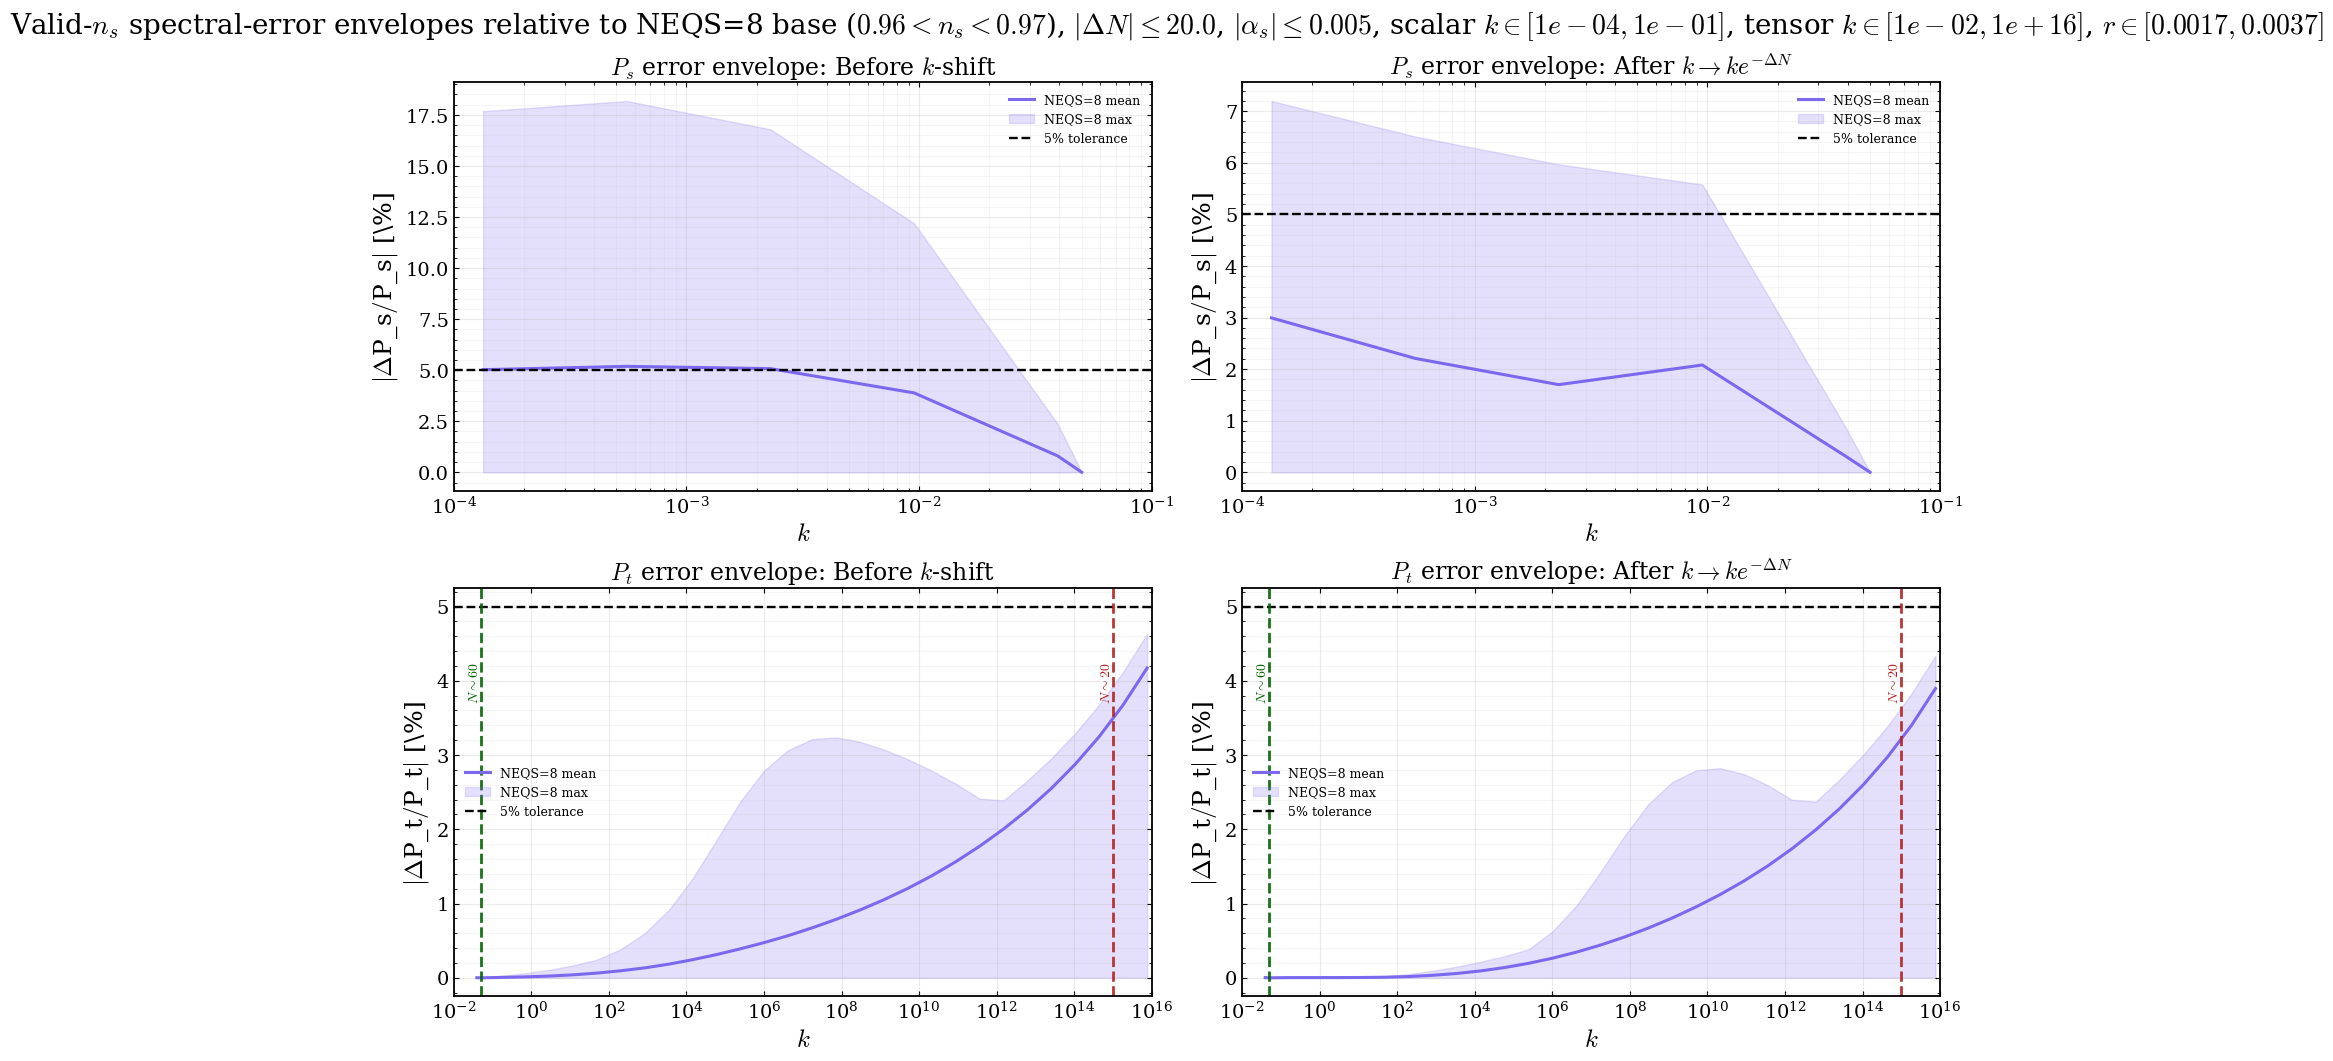


=== Cut summary ===
NEQS=8: kept=137, skipped_ns=0, skipped_r=0, skipped_alpha=51, skipped_deltaN=0, skipped_other=12

=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  k_min_tensor  k_max_tensor  max_abs_deltaN_cut  max_abs_alpha_s_cut    r_min    r_max
    8 Ps_unshift       137             4.457453         18.180841        0.0001           0.1           NaN           NaN                20.0                0.005 0.001737 0.003737
    8   Ps_shift       137             1.889545          7.196746        0.0001           0.1           NaN           NaN                20.0                0.005 0.001737 0.003737
    8 Pt_unshift       137             0.619596          4.634123           NaN           NaN          0.01  1.000000e+16                20.0                0.005 0.001737 0.003737
    8   Pt_shift       137             0.393030          4.339245           NaN           NaN          0.01  1.000000e+16          

In [55]:
model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes_rminmax_tensorK_batch(
    base_path_root=base_path_root,
    lam_values_by_neqs={8: lam5_values},
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    model_tag="higgs",

    ns_min=0.96,
    ns_max=0.97,
    r_min=2.737e-03 - 0.001,
    r_max=2.737e-03 + 0.001,
    max_abs_alpha_s=0.005,

    k_norm=0.05,

    k_min_scalar=1e-4,
    k_max_scalar=1e-1,

    k_min_tensor=1e-2,
    k_max_tensor=1e16,

    max_abs_deltaN=20.0,
    tolerance=5.0,
    skip_zero=True,
    save_name="valid_ns_r_alpha_tensorK_before_after_kshift.png",
)

Consider displaing 

In [64]:
def plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    model_tag="higgs",
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    alpha_min=None,
    alpha_max=None,
    max_abs_alpha_s=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    k_min_tensor=None,
    k_max_tensor=None,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    show_max=True,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 10,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    summary_cache = {}

    def get_summary(NEQS):
        if NEQS not in summary_cache:
            summary_cache[NEQS] = load_batch_summaries(
                NEQS,
                base_path_root,
                model_tag=model_tag,
            )
        return summary_cache[NEQS]

    def get_summary_row(NEQS, param_name, value):
        summary_df = get_summary(NEQS)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return matches.iloc[0]

    def load_observables(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return row["r"], row["n_s"], row["alpha_s"]

    def get_original_N_end(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return float(row["original_N_end"])

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(
            NEQS,
            param_name,
            value,
            model_tag=model_tag,
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    def collect_percentile_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        return {
            "k": k_env,
            "median": 100.0 * np.nanmedian(abs_stack, axis=0),
            "p68": 100.0 * np.nanpercentile(abs_stack, 68, axis=0),
            "p95": 100.0 * np.nanpercentile(abs_stack, 95, axis=0),
            "max": 100.0 * np.nanmax(abs_stack, axis=0),
        }

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_alpha": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if alpha_min is not None and alpha_s < alpha_min:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if alpha_max is not None and alpha_s > alpha_max:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if max_abs_alpha_s is not None and np.abs(alpha_s) > max_abs_alpha_s:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                # Shifted
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            env = collect_percentile_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if env is None:
                continue

            k_env = env["k"]
            median = env["median"]
            p68 = env["p68"]
            p95 = env["p95"]
            max_env = env["max"]

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            median = median[mask]
            p68 = p68[mask]
            p95 = p95[mask]
            max_env = max_env[mask]

            if len(k_env) == 0:
                continue

            ax.fill_between(
                k_env,
                0.0,
                p95,
                color=color,
                alpha=0.16,
                label=rf"NEQS={NEQS} 95% spread",
            )

            ax.fill_between(
                k_env,
                0.0,
                p68,
                color=color,
                alpha=0.30,
                label=rf"NEQS={NEQS} 68% spread",
            )

            ax.plot(
                k_env,
                median,
                color=color,
                lw=2.5,
                label=rf"NEQS={NEQS} median",
            )

            if show_max:
                ax.plot(
                    k_env,
                    max_env,
                    color=color,
                    lw=1.25,
                    ls=":",
                    alpha=0.9,
                    label=rf"NEQS={NEQS} max",
                )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_abs_pct": np.nanmedian(median),
                "max_p68_abs_pct": np.nanmax(p68),
                "max_p95_abs_pct": np.nanmax(p95),
                "max_envelope_pct": np.nanmax(max_env),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "k_min_tensor": k_min_tensor if "Pt" in key else np.nan,
                "k_max_tensor": k_max_tensor if "Pt" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "max_abs_alpha_s_cut": max_abs_alpha_s,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        if "Pt" in key:
            k_N60 = 0.05
            k_N20 = 1e15

            ax.axvline(k_N60, color="darkgreen", ls="--", lw=1.8, alpha=0.9)
            ax.axvline(k_N20, color="firebrick", ls="--", lw=1.8, alpha=0.9)

            ax.text(
                k_N60,
                0.82,
                r"$N\sim60$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="darkgreen",
                ha="right",
                va="top",
                fontsize=10,
            )

            ax.text(
                k_N20,
                0.82,
                r"$N\sim20$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="firebrick",
                ha="right",
                va="top",
                fontsize=10,
            )

        ax.set_xscale("log")
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} percentile envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(fontsize=8, frameon=False, loc="best")

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if max_abs_alpha_s is not None:
        cut_text += rf", $|\alpha_s| \leq {max_abs_alpha_s}$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Percentile spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_tensorK_percentile_envelopes_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_alpha={curves[NEQS]['skipped_alpha']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Percentile envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    return model_df, envelope_df

Skipping NEQS=8, lam5=-4.98273e-05: k_ref=0.05 outside range [5.478e-02, 6.496e+22]
Skipping NEQS=8, lam5=-4.67033e-05: k_ref=0.05 outside range [6.074e-02, 7.202e+22]
Skipping NEQS=8, lam5=-4.61757e-05: k_ref=0.05 outside range [5.705e-02, 6.765e+22]
Skipping NEQS=8, lam5=-4.47804e-05: k_ref=0.05 outside range [6.233e-02, 7.390e+22]
Skipping NEQS=8, lam5=-3.98596e-05: k_ref=0.05 outside range [7.226e-02, 8.568e+22]
Skipping NEQS=8, lam5=-3.34655e-05: k_ref=0.05 outside range [7.214e-02, 8.554e+22]
Skipping NEQS=8, lam5=-2.31198e-05: k_ref=0.05 outside range [5.174e-02, 6.135e+22]
Skipping NEQS=8, lam5=-1.49233e-05: k_ref=0.05 outside range [1.141e-01, 1.352e+23]
Skipping NEQS=8, lam5=-1.21391e-05: k_ref=0.05 outside range [1.224e-01, 1.452e+23]
Skipping NEQS=8, lam5=-9.25599e-06: k_ref=0.05 outside range [9.250e-02, 1.097e+23]
Skipping NEQS=8, lam5=-6.85582e-06: k_ref=0.05 outside range [6.415e-02, 7.606e+22]
Skipping NEQS=8, lam5=1.66952e-06: k_ref=0.05 outside range [1.244e-01, 1.47

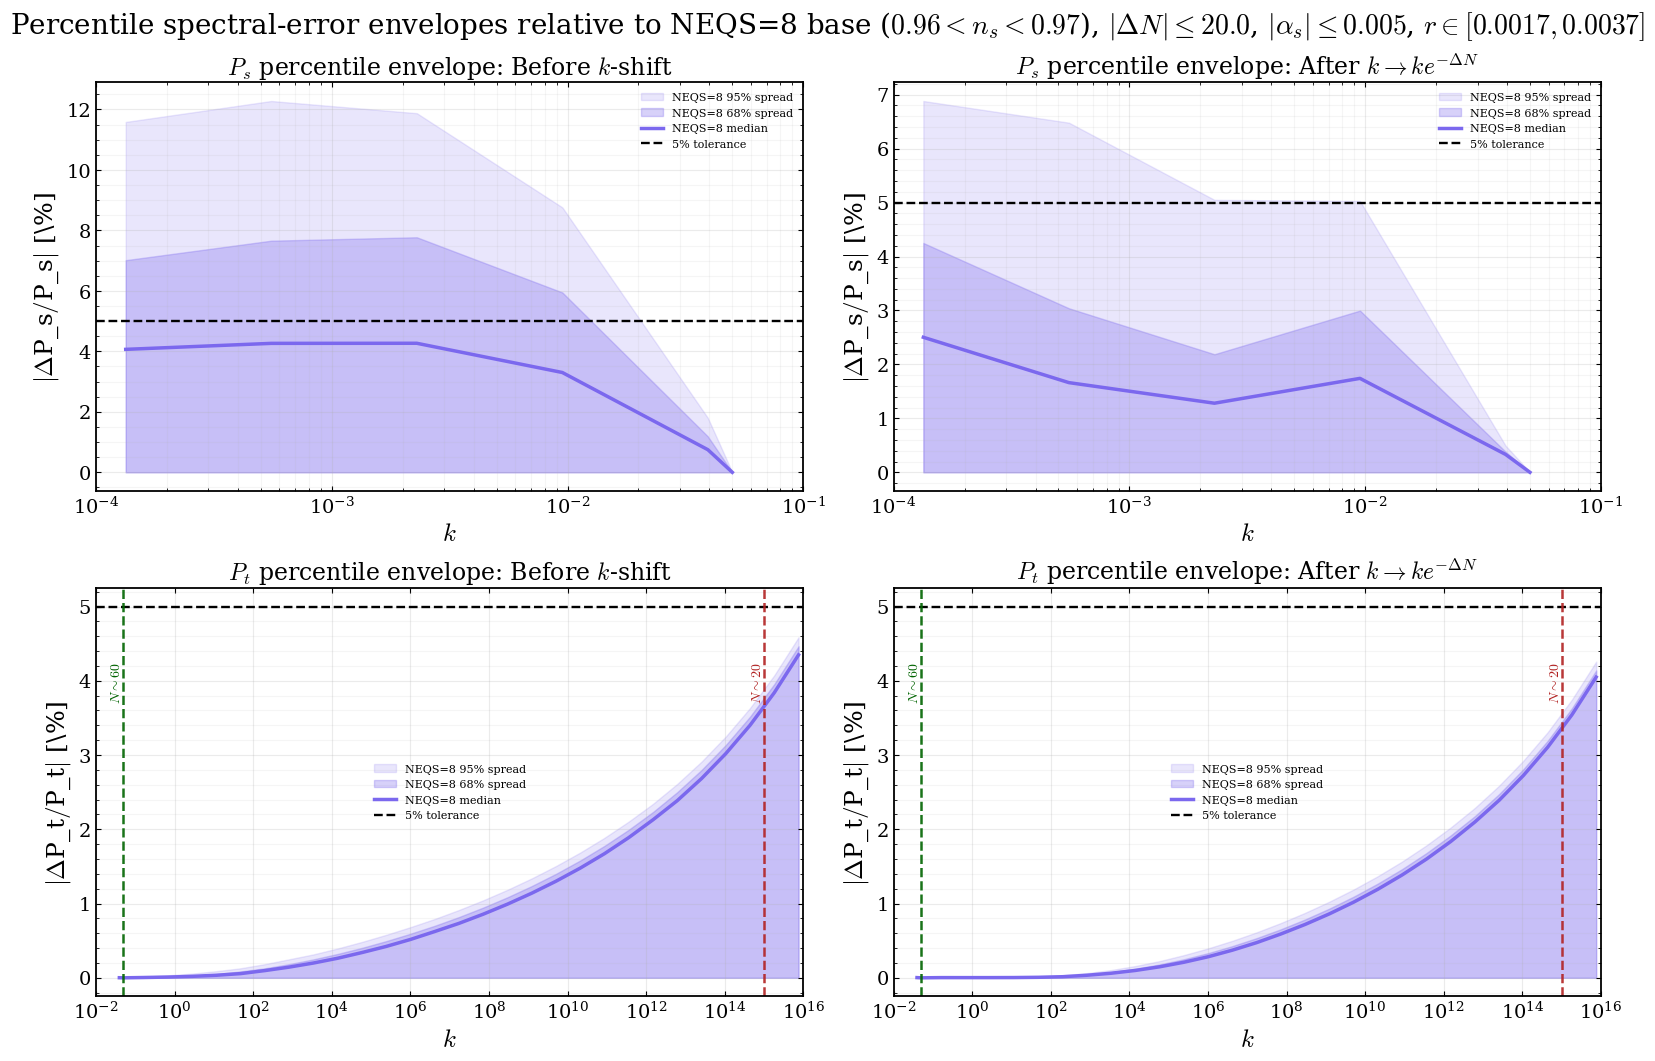


=== Cut summary ===
NEQS=8: kept=137, skipped_ns=0, skipped_r=0, skipped_alpha=51, skipped_deltaN=0, skipped_other=12

=== Percentile envelope summary ===
 NEQS       case  n_models  median_abs_pct  max_p68_abs_pct  max_p95_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  k_min_tensor  k_max_tensor  max_abs_deltaN_cut  max_abs_alpha_s_cut    r_min    r_max
    8 Ps_unshift       137        3.683072         7.772518        12.277954         18.180841        0.0001           0.1           NaN           NaN                20.0                0.005 0.001737 0.003737
    8   Ps_shift       137        1.471815         4.251109         6.883157          7.196746        0.0001           0.1           NaN           NaN                20.0                0.005 0.001737 0.003737
    8 Pt_unshift       137        0.678159         4.464515         4.585778          4.634123           NaN           NaN          0.01  1.000000e+16                20.0                0.005 0.001737 0.003737
    

In [65]:
model_df_pct, envelope_df_pct = plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
    base_path_root=base_path_root,
    lam_values_by_neqs={8: lam5_values},
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    model_tag="higgs",

    ns_min=0.96,
    ns_max=0.97,
    r_min=2.737e-03 - 0.001,
    r_max=2.737e-03 + 0.001,
    max_abs_alpha_s=0.005,

    k_norm=0.05,

    k_min_scalar=1e-4,
    k_max_scalar=1e-1,

    k_min_tensor=1e-2,
    k_max_tensor=1e16,

    max_abs_deltaN=20.0,
    tolerance=5.0,
    skip_zero=True,
    show_max=False,
    save_name="valid_ns_r_alpha_tensorK_percentile_envelopes.png",
)

Okay so after applyiong the shift in N, you can see that the median scalar spectral shift for the 137 kept models (alpha_s cut applied here) decreases after the shift is applied. Tensor spectra pass within this threshold very very well. For scalars, 68% remain below 5% truncation threshold, but there is a small tail of outliers above that threshold, around maybe 7%. 

68% of the surviving models have scalar spectral errors below 4.25% everywhere in the plotted range. 95% of models stay below about 6.9%, with only a tiny tail behaving worse.